# RQ1 --- Effectiveness

In [1]:
import sys

sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt
from experiments._loader import load_all_results, success_only
from experiments._analysis import (
    PALETTE,
    tex,
    compute_image_metrics,
    compute_text_metrics,
    SPLIT_LABEL,
    SPLIT_ORDER,
)
import matplotlib as mpl

mpl.rcParams.update(
    {
        "text.usetex": True,
        "text.latex.preamble": r"\usepackage{amsmath}",
        "font.family": "serif",
        "font.size": 20,
        "axes.titlesize": 22,
        "axes.labelsize": 20,
        "xtick.labelsize": 20,
        "ytick.labelsize": 16,
        "legend.fontsize": 16,
        "legend.title_fontsize": 16,
        "figure.titlesize": 22,
    }
)

df_all = load_all_results(include_baseline_fail=True)
df_opt = success_only(df_all)

THRESHOLDS = np.arange(0.0, 1.1, 0.1)  # 0.0, 0.1, ..., 0.9

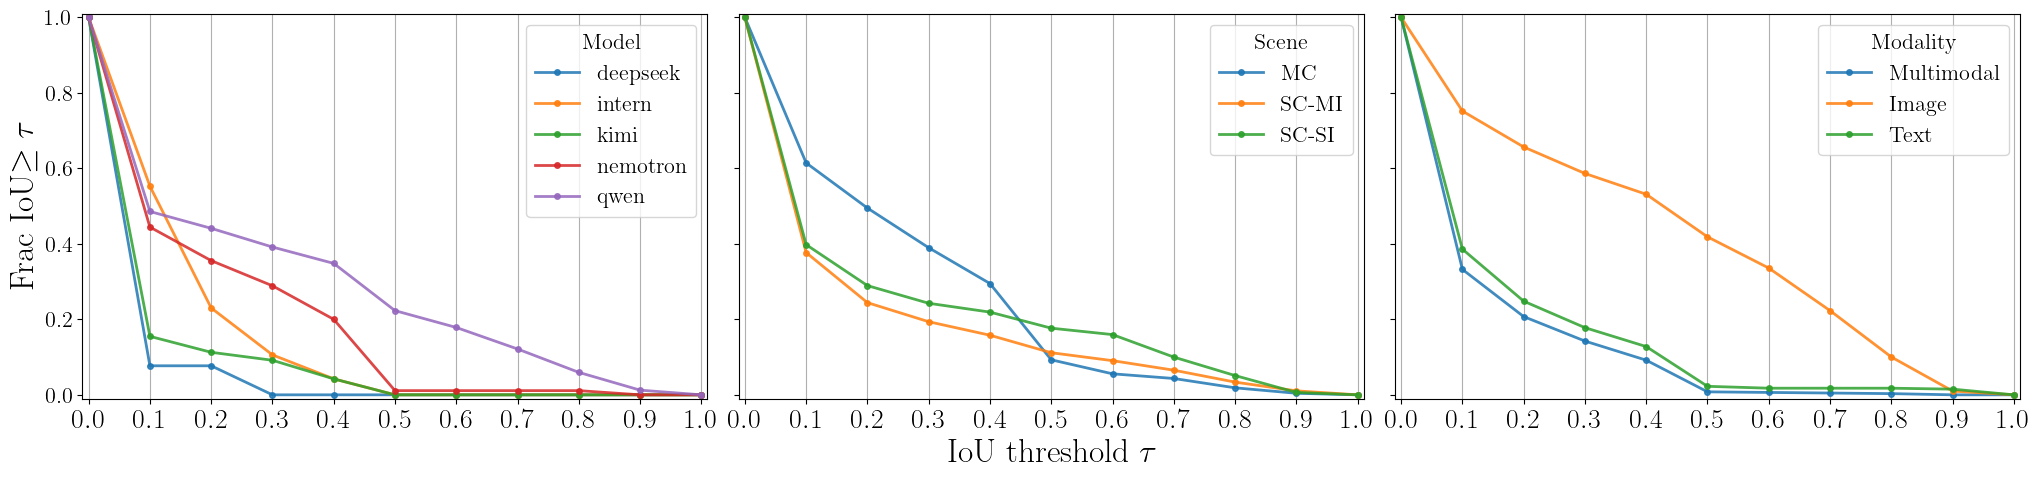

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(25, 5), sharey=True)
fig.subplots_adjust(wspace=0.05)

# 1) By model
ax = axes[0]
for i, model in enumerate(sorted(df_opt["model"].unique())):
    sub = df_opt[df_opt["model"] == model]
    if df_opt[df_opt["model"] == model].size < 30:
        continue
    ax.plot(
        THRESHOLDS,
        [(sub["final_iou"] >= t).mean() for t in THRESHOLDS],
        lw=2,
        label=tex(model),
        color=PALETTE[i],
        alpha=0.85,
        marker="o",
        markersize=4,
    )
##ax.set_xlabel(r'IoU threshold $\tau$')
ax.set_ylabel(r"Frac IoU$\geq\tau$", fontsize=24)
ax.set_xticks(THRESHOLDS)
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.01)
ax.legend(title="Model")
ax.grid(axis="x")

# 2) By scene
SCENE_ALIAS = {
    "multi": "MC",
    "single/multi": "SC-MI",
    "single/solo": "SC-SI",
}

ax = axes[1]
for scene, label in SCENE_ALIAS.items():
    sub = df_opt[df_opt["obj_category"] == scene]
    if sub.empty:
        continue
    ax.plot(
        THRESHOLDS,
        [(sub["final_iou"] >= t).mean() for t in THRESHOLDS],
        lw=2,
        label=label,
        alpha=0.85,
        marker="o",
        markersize=4,
    )
ax.set_xlabel(r"IoU threshold $\tau$", fontsize=24)
ax.set_xticks(THRESHOLDS)
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.01)
ax.legend(title="Scene")
ax.grid(axis="x")

# 3) By modality
MODALITY_ALIAS = {
    "multi": "Multimodal",
    "image": "Image",
    "text": "Text",
}

ax = axes[2]
for modality, label in MODALITY_ALIAS.items():
    sub = df_opt[df_opt["genome_mode"] == modality]
    if sub.empty:
        continue
    ax.plot(
        THRESHOLDS,
        [(sub["final_iou"] >= t).mean() for t in THRESHOLDS],
        lw=2,
        label=label,
        alpha=0.85,
        marker="o",
        markersize=4,
    )
# ax.set_xlabel(r'IoU threshold $\tau$')
ax.set_xticks(THRESHOLDS)
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.01)
ax.legend(title="Modality")
ax.grid(axis="x")
plt.savefig("figures/curves_rq1.pdf", dpi=200, bbox_inches="tight")

In [3]:
df_opt = compute_image_metrics(df_opt)
df_txt = compute_text_metrics(df_opt[df_opt["genome_mode"].isin(["multi", "text"])].copy())
EMPTY = {
    "frac@0.25": "---",
    "frac@0.50": "---",
    "SSIM_mean": "---",
    "SSIM_std": "---",
    "NED_mean": "---",
    "NED_std": "---",
}
rows = []

for model in sorted(df_all["model"].unique()):
    for key in SPLIT_ORDER:
        mod, gmode, cat = key

        sub_all = df_all[
            (df_all["model"] == model)
            & (df_all["modality"] == mod)
            & (df_all["genome_mode"] == gmode)
            & (df_all["obj_category"] == cat)
        ]

        if sub_all.empty:
            line = (
                " & ".join([tex(model), SPLIT_LABEL[key], "---", "---", "---", "---", "---"])
                + r" \\"
            )

            rows.append(line)
            continue

        fail_rate = (sub_all["status"] == "baseline_fail").mean()

        sub_opt = df_opt[
            (df_opt["model"] == model)
            & (df_opt["modality"] == mod)
            & (df_opt["genome_mode"] == gmode)
            & (df_opt["obj_category"] == cat)
        ]

        if fail_rate > 0.90 or sub_opt.empty:
            vals = ["---"] * 5

        else:
            frac25 = f"{(sub_all['final_iou'] <= 0.25).mean():.2f}"
            frac50 = f"{(sub_all['final_iou'] <= 0.50).mean():.2f}"

            ms = sub_opt["ms_ssim"].dropna()
            if len(ms):
                ssim = f"${ms.mean():.3f} \\pm {ms.std():.3f}$"
            else:
                ssim = "---"

            if gmode in ("multi", "text"):
                nd = df_txt[
                    (df_txt["model"] == model)
                    & (df_txt["genome_mode"] == gmode)
                    & (df_txt["obj_category"] == cat)
                ]["ned"].dropna()

                ned = f"${nd.mean():.3f} \\pm {nd.std():.3f}$" if len(nd) else "---"
            else:
                ned = "N/A"

            vals = [
                f"{fail_rate:.2f}",
                frac25,
                frac50,
                ssim,
                ned,
            ]

        line = " & ".join([tex(model), SPLIT_LABEL[key], *vals]) + r" \\"

        rows.append(line)

print("Failrate, Frac25, Frac50, SSIM, CER")
print("\n".join(rows))

Failrate, Frac25, Frac50, SSIM, CER
deepseek & multimodal-multi & --- & --- & --- & --- & --- \\
deepseek & multimodal-single-multi & --- & --- & --- & --- & --- \\
deepseek & multimodal-single-solo & --- & --- & --- & --- & --- \\
deepseek & image-multi & --- & --- & --- & --- & --- \\
deepseek & image-single-multi & --- & --- & --- & --- & --- \\
deepseek & image-single-solo & --- & --- & --- & --- & --- \\
deepseek & text-multi & --- & --- & --- & --- & --- \\
deepseek & text-single-multi & --- & --- & --- & --- & --- \\
deepseek & text-single-solo & --- & --- & --- & --- & --- \\
gemma & multimodal-multi & --- & --- & --- & --- & --- \\
gemma & multimodal-single-multi & --- & --- & --- & --- & --- \\
gemma & multimodal-single-solo & --- & --- & --- & --- & --- \\
gemma & image-multi & --- & --- & --- & --- & --- \\
gemma & image-single-multi & --- & --- & --- & --- & --- \\
gemma & image-single-solo & --- & --- & --- & --- & --- \\
gemma & text-multi & --- & --- & --- & --- & --- \

/home/weissl/miniconda3/envs/hynea/lib/python3.12/site-packages/numpy/_core/_methods.py:51: ComplexWarning: Casting complex values to real discards the imaginary part
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


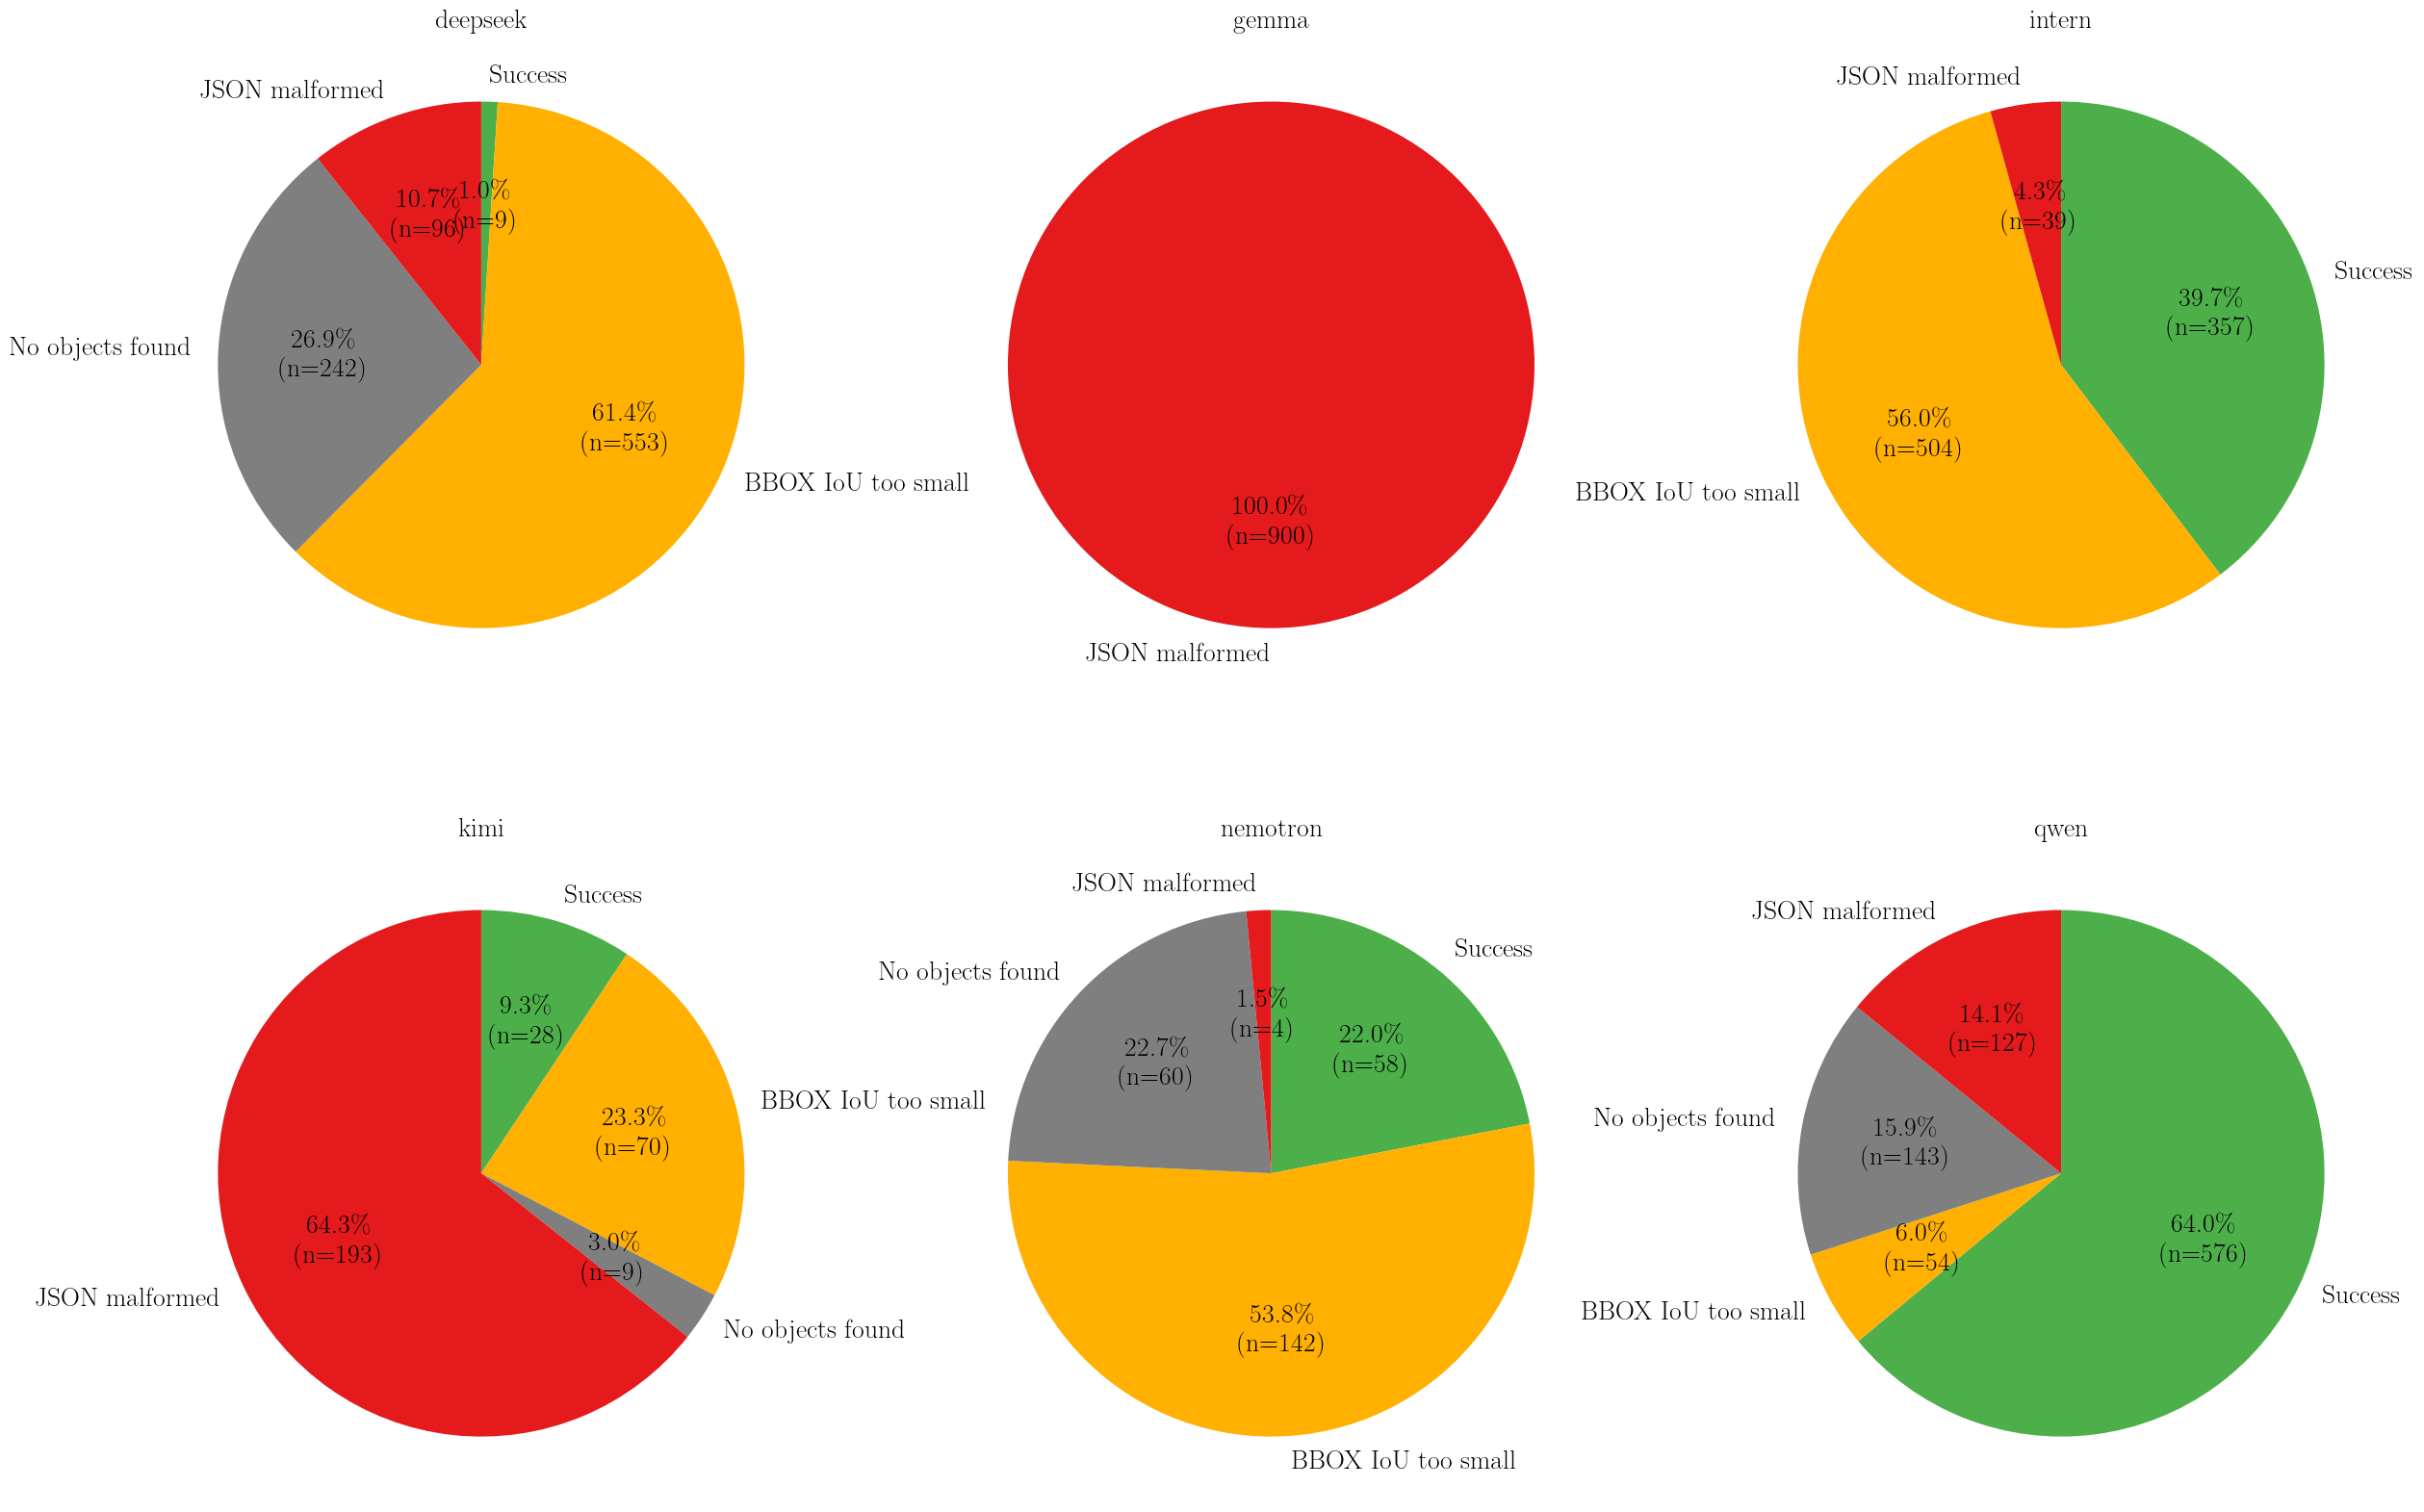

In [7]:
from experiments._analysis import classify_termination_series, TERMINATION_ORDER, TERMINATION_COLORS

term_df = classify_termination_series(df_all)
models = sorted(term_df["model"].dropna().unique())


def autopct_with_counts(values):
    total = int(sum(values))

    def _fmt(pct):
        count = int(round(pct * total / 100.0))
        return f"{pct:.1f}%\n(n={count})" if count > 0 else ""

    return _fmt


fig, axes = plt.subplots(2, len(models) // 2, figsize=(10 * len(models) // 2, 20), squeeze=False)
axes = axes.ravel()

for ax, model in zip(axes, models):
    sub = term_df[term_df["model"] == model]
    counts = sub["termination_type"].value_counts()
    labels = [label for label in TERMINATION_ORDER if counts.get(label, 0) > 0]
    values = [int(counts[label]) for label in labels]
    colors = [TERMINATION_COLORS[label] for label in labels]

    ax.pie(
        values,
        labels=labels,
        colors=colors,
        autopct=autopct_with_counts(values),
        startangle=90,
        counterclock=False,
        textprops={"fontsize": 20},
    )
    ax.set_title(tex(model), fontsize=20)

for ax in axes[len(models) :]:
    ax.axis("off")

plt.savefig("figures/pies.png", dpi=200, bbox_inches="tight")